<a href="https://colab.research.google.com/github/rajivbandaru97/Credit-Risk-Analytics/blob/initial/ECL_Model_IFRS9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing dependencies

In [ ]:
pip install numpy pandas scikit-learn matplotlib seaborn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.2 MB/s eta 0:00:00


# Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

# Configuring the plotting parameters

In [2]:
sns.set_theme(style="whitegrid")
%matplotlib inline

print("✅ Dependencies imported successfully!")

✅ Dependencies imported successfully!


# Importing the data

In [5]:
data_backup = pd.read_csv('/content/german_credit_data.csv')

# Explore the data

In [6]:
data = data_backup

In [7]:
data.columns.values
#displays all the columns present

array(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype=object)

In [8]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [9]:
data.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


In [10]:
data = data.fillna(0)
display(data.head())
#Filling missing values as zeroes

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,0,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,0,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


# Exposure at Default and staging the architecture

We will be now calculating here the exposure at default for the same

In [12]:
#Declaring the CCF using default value. CCF is usually 0.20

CCF = 0.20

#Computing EAD
data['EAD'] = data['Credit amount'] * (1.0 + CCF)

#Staging function based on significant increase in credit risk

def assign_ifrs_stage(row):
  #Stage3: Extreme duration combined with huge cash duress
  if row['Checking account'] == 'little' and row['Duration'] >= 45:
    return 3

  #stage 2: Signal of technical deterioration or extending term
  if row['Checking account'] == 'little' or row['Duration'] > 24:
    return 2

  #stage 1: Healthy performance profile
  else:
    return 1

data['IFRS_Stage'] = data.apply(assign_ifrs_stage, axis=1)

#Review staging distribution percentages
print(data['IFRS_Stage'].value_counts(normalize=True).sort_index() * 100)



IFRS_Stage
1    56.0
2    42.1
3     1.9
Name: proportion, dtype: float64


# Training the probability of Default Engine

We will be isolating categorical fields from numerical attributes, scale numeric values, apply one-hot transformations, and train a pipeline using Logistic Regression.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

#define the proxy binary default flag for predictive baseline training

np.random.seed(42)

data['Historical_default'] = np.where(
    (data['IFRS_Stage'] == 3) |
    ((data['Checking account'] == 'little') & (data['Age'] < 30) & (np.random.rand(len(data)) > 0.40)), # Added missing comma here
    1,
    0
    )


#Matrix assignment feature

numeric_features = ['Age', 'Credit amount', 'Duration']
categorical_features = ['Sex', 'Housing', 'Purpose']

X = data[numeric_features + categorical_features] # Corrected X definition
y = data['Historical_default'] # Corrected y definition

#Splitting the data into train and test for validation folds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

# Construct preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Execute complete model integration path
pd_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pd_pipeline.fit(X_train, y_train)

# Evaluate model validation metrics
test_preds = pd_pipeline.predict_proba(X_test)[:, 1]
print(f" Model ROC-AUC Score: {roc_auc_score(y_test, test_preds):.2%}\n")
print(classification_report(y_test, pd_pipeline.predict(X_test)))

 Model ROC-AUC Score: 75.95%

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       276
           1       0.19      0.67      0.29        24

    accuracy                           0.74       300
   macro avg       0.58      0.71      0.57       300
weighted avg       0.90      0.74      0.80       300



# Forward looking macro-adjustments and provisioning

This cell extracts the model probabilities, subjects them to dynamic Macroeconomic Scenarios (Base, Upside, Downside), and assigns calculated impairment provisions

In [15]:
#Macroeconomic shift and final IFRS9 ECL matrix
#Generate baseline Point in Time (PIT) probabilities

data['Base_PD'] = pd_pipeline.predict_proba(X)[:, 1]

#Macro factors parameters

w_base, w_upside, w_downside = 0.60, 0.20, 0.20

scaler_upside, scaler_downside = 0.80, 1.40

#Adjust probabilities across multiple macroeconomic zones
data['Upside_PD'] = np.minimum(data['Base_PD'] * scaler_upside, 1.0)
data['Downside_PD'] = np.minimum(data['Base_PD'] * scaler_downside, 1.0)

# Calculate final weighted Forward-Looking PD
data['Forward_Looking_PD'] = (data['Base_PD'] * w_base) + (data['Upside_PD'] * w_upside) + (data['Downside_PD'] * w_downside)

# Apply rule override: Stage 3 defaulted assets are anchored at 100% PD
data.loc[data['IFRS_Stage'] == 3, 'Forward_Looking_PD'] = 1.0

# Assign regulatory loss baseline parameter (LGD)
data['LGD'] = 0.45  # Unsecured regulatory standard

# Standard IFRS 9 ECL Formula Execution
data['ECL'] = data['Forward_Looking_PD'] * data['LGD'] * data['EAD']

# Aggregate provisions matrix summary table
ecl_summary = data.groupby('IFRS_Stage').agg(
    Loan_Count=('Age', 'count'),
    Total_EAD=('EAD', 'sum'),
    Weighted_Avg_PD=('Forward_Looking_PD', 'mean'),
    Total_ECL_Provisions=('ECL', 'sum')
).reset_index()

# Formatting financial layout lookahead
ecl_summary.style.format({
    'Total_EAD': '${:,.2f}',
    'Weighted_Avg_PD': '{:.2%}',
    'Total_ECL_Provisions': '${:,.2f}'
})

,IFRS_Stage,Loan_Count,Total_EAD,Weighted_Avg_PD,Total_ECL_Provisions
0,1,560,"$1,627,596.00",29.50%,"$191,182.27"
1,2,421,"$2,146,989.60",43.67%,"$405,866.32"
2,3,19,"$150,924.00",100.00%,"$67,915.80"


# Diagnostic Visualisations

/tmp/ipykernel_965/3176331095.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ecl_summary, x='IFRS_Stage', y='Total_ECL_Provisions', ax=ax1, palette='coolwarm')
/tmp/ipykernel_965/3176331095.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['IFRS_Stage'] != 3], x='IFRS_Stage', y='Forward_Looking_PD', ax=ax2, palette='coolwarm')


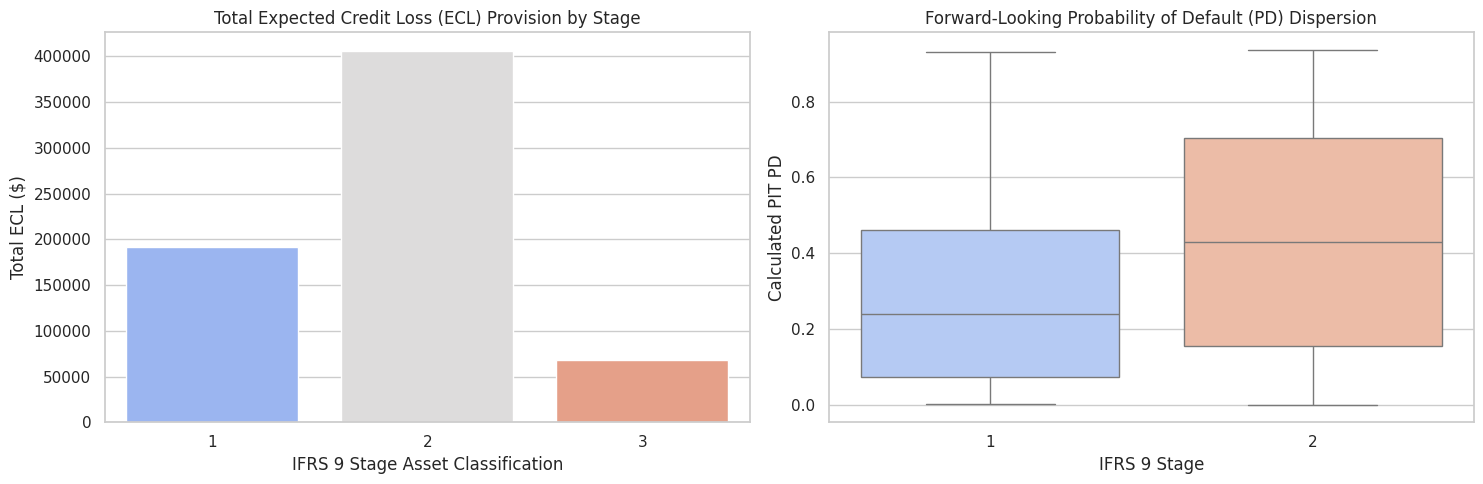

In [18]:
# Cell 6: Risk Spread Diagnostics plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Total provisions across asset groupings
sns.barplot(data=ecl_summary, x='IFRS_Stage', y='Total_ECL_Provisions', ax=ax1, palette='coolwarm')
ax1.set_title("Total Expected Credit Loss (ECL) Provision by Stage")
ax1.set_ylabel("Total ECL ($)")
ax1.set_xlabel("IFRS 9 Stage Asset Classification")

# Plot 2: Statistical probability box spreads
sns.boxplot(data=data[data['IFRS_Stage'] != 3], x='IFRS_Stage', y='Forward_Looking_PD', ax=ax2, palette='coolwarm')
ax2.set_title("Forward-Looking Probability of Default (PD) Dispersion")
ax2.set_ylabel("Calculated PIT PD")
ax2.set_xlabel("IFRS 9 Stage")

plt.tight_layout()
plt.show()